## This notebook describes Machine learning and active learning workflow for screening Piezoelectric Mxenes. 
### The overview of the procedure followed is shown below.
<img src="overview.png" width="400">

### Below is the procedure followed for traditional ML Path using monoatomic MXenes.
<img src="ML.png" width="400">

#### Featurization is performed using inhouse codes and matminer package (https://matminer.readthedocs.io/en/latest/)

In [1]:
from matminer.utils.io import load_dataframe_from_json, store_dataframe_as_json
import pandas as pd
import numpy as np
# filter warnings messages from the notebook
import warnings
warnings.filterwarnings('ignore')

df_x = load_dataframe_from_json("monoatomic_mxene.json")
df_x['Piezo_11 (pm/V)'] = [abs(array[1][1]) * 10 for array in df_x['total_piezo_tensor']]
df_x['Piezo_31 (pm/V)'] = [abs(array[2][0]) * 10 for array in df_x['total_piezo_tensor']] 
df_x['Piezo_33 (pm/V)'] = [abs(array[2][2]) * 10 for array in df_x['total_piezo_tensor']]

Reading file monoatomic_mxene.json: 0it [00:01, ?it/s]##################################################   | 353/372 [00:01<00:00, 482.19it/s]
Decoding objects from monoatomic_mxene.json: 100%|#########################################################| 372/372 [00:01<00:00, 276.69it/s]


In [2]:
#exclude electronic, bonding and elastic features
exclude1 = ['Icohp_mean_avg', 'Icohp_mean_max', 'Icohp_mean_min', 'Icohp_mean_std', 'Icohp_sum_avg',
          'Icohp_sum_max', 'Icohp_sum_min', 'Icohp_sum_std', 'bonding_perc_avg', 'bonding_perc_max',
          'bonding_perc_min', 'bonding_perc_std', 'antibonding_perc_avg', 'antibonding_perc_min', 
          'antibonding_perc_max', 'antibonding_perc_std', 'Madelung_Mull', 'Madelung_Loew', 'bnd_wICOHP', 
          'antibnd_wICOHP', 'w_ICOHP', 'EIN_ICOHP', 'center_COHP', 'width_COHP', 'skewness_COHP', 'kurtosis_COHP', 
          'edge_COHP', 'Ionicity_Mull', 'Ionicity_Loew', 'total_energy', 'HEf', 'thickness', 'Omega',
          'BORN_charges_TM', 'max_born_charge', 'max_dielectric', 
          'C11(N/m)', 'C12(N/m)', 'C66(N/m)', '2D_Poisson_ratio', 'Youngs_Modulus(N/m)', 
          'Shear_Modulus(N/m)', 'Bulk_modulus(N/m)', 'Bulk/Shear', 'a', 'c']

df = df_x.drop(exclude1, axis=1)

In [3]:
# Add density, composition and structural feaures using matminer

from matminer.featurizers.structure import DensityFeatures
df_feat = DensityFeatures()
df = df_feat.featurize_dataframe(df, "structure")  # input the structure column to the featurizer

from matminer.featurizers.conversions import StrToComposition
df = StrToComposition().featurize_dataframe(df, "Mxenes")
from matminer.featurizers.conversions import CompositionToOxidComposition
from matminer.featurizers.composition import OxidationStates

df = CompositionToOxidComposition().featurize_dataframe(df, "composition")

os_feat = OxidationStates()
df = os_feat.featurize_dataframe(df, "composition_oxid")

from matminer.datasets.convenience_loaders import load_elastic_tensor
from matminer.featurizers.structure import SiteStatsFingerprint
cnnf = SiteStatsFingerprint.from_preset("CrystalNNFingerprint_ops")
df = cnnf.featurize_dataframe(df, "structure", len(df["structure"][:])-1, True)

from matminer.featurizers.structure import SiteStatsFingerprint
from matminer.featurizers.site import AverageBondAngle, AverageBondLength
from pymatgen.analysis.local_env import CrystalNN

featurizer = SiteStatsFingerprint.from_preset('CrystalNNFingerprint_ops')

structures  = df["structure"]

# Compute the features (bond lengths and angles) for each structure in the DataFrame
df['features'] = structures.apply(lambda s: featurizer.featurize(s)[0])

#nnalgo = CrystalNN()
#bl = AverageBondLength(nnalgo)

#sspbl = SiteStatsFingerprint(site_featurizer=bl)
#df2 = sspbl.featurize_dataframe(df1, ignore_errors=True)
#print(df2)

SiteStatsFingerprint: 100%|█████████████████████████████████████████████████████████████████████████████████| 124/124 [00:21<00:00,  5.90it/s]


In [4]:
y = df['Piezo_31 (pm/V)'].values

# remove strings and other features

excluded =  ['compounds', 'name', 'Mxenes', 'structure', 'total_piezo_tensor',
            'total_dielectric_tensor', 'composition', 
             'composition_oxid', 'SiteStatsFingerprint Exceptions', 
             'Piezo_31 (pm/V)','Piezo_33 (pm/V)', 'Piezo_11 (pm/V)','max_piezo']

X = df.drop(excluded, axis=1)

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Split the data into training and testing sets
X_train1, X_test1, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train1)
X_test = scaler.transform(X_test1)

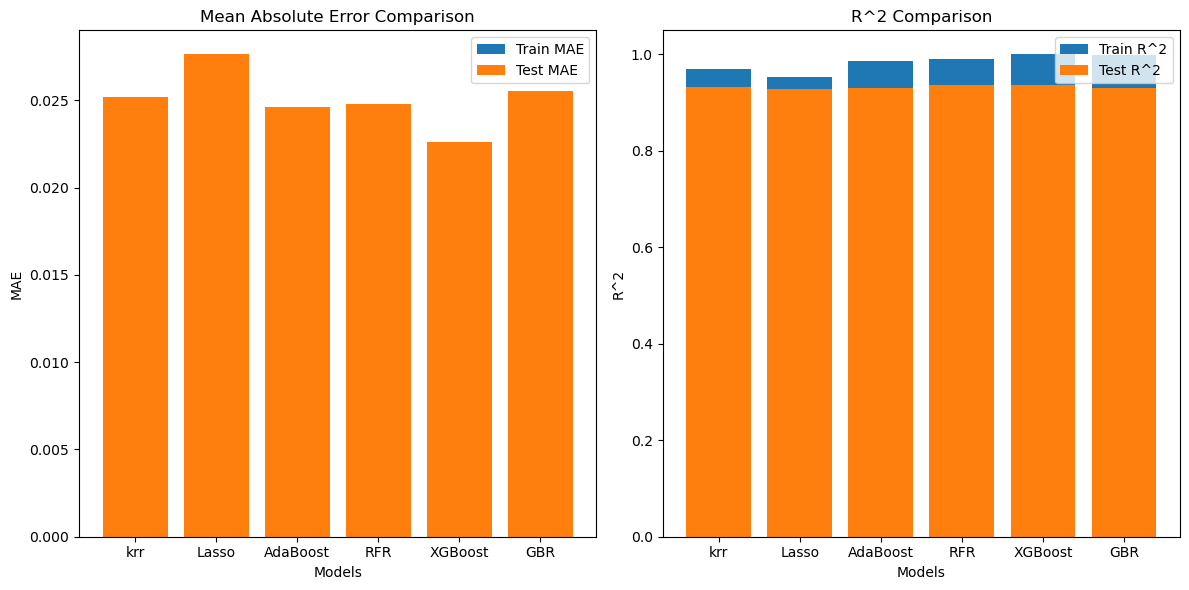

In [5]:
import numpy as np
from sklearn.linear_model import Lasso
from sklearn.kernel_ridge import KernelRidge
from sklearn.ensemble import AdaBoostRegressor, RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt

# Initialize models
models = {
    'krr': KernelRidge(),
    'Lasso': Lasso(),
    'AdaBoost': AdaBoostRegressor(),
    'RFR': RandomForestRegressor(),
    'XGBoost': xgb.XGBRegressor(),
    'GBR': GradientBoostingRegressor()
}

# Define hyperparameters for tuning
param_grid = {
    'krr': {'alpha': [0.001, 0.01, 0.1, 1, 10], 'kernel': ['linear', 'rbf', 'poly'], 'gamma': [0.01, 0.1, 1.0]},
    'Lasso': {'alpha': [0.001, 0.01, 0.1, 1, 10]},
    'AdaBoost': {'n_estimators': [50, 100, 200]},
    'RFR': {'n_estimators': [50, 100, 200], 'max_depth': [None, 10, 20]},
    'XGBoost': {'n_estimators': [50, 100, 200], 'learning_rate': [0.01, 0.1, 0.2]},
    'GBR': {'n_estimators': [50, 100, 200], 'learning_rate': [0.01, 0.1, 0.2]}
}

mae_train_scores = {}
mae_test_scores = {}
r2_train_scores = {}
r2_test_scores = {}

for model_name, model in models.items():
    # Perform hyperparameter tuning using GridSearchCV
    if model_name in param_grid:
        grid_search = GridSearchCV(model, param_grid[model_name], scoring='neg_mean_absolute_error', cv=10)
        grid_search.fit(X_train, y_train)
        model = grid_search.best_estimator_
    
    # Fit the model
    model.fit(X_train, y_train)
    
    # Predict on the training and test data
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Calculate MAE and R^2 scores
    mae_train = mean_absolute_error(y_train, y_train_pred)
    mae_test = mean_absolute_error(y_test, y_test_pred)
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)
    
    # Store the scores
    mae_train_scores[model_name] = mae_train
    mae_test_scores[model_name] = mae_test
    r2_train_scores[model_name] = r2_train
    r2_test_scores[model_name] = r2_test

# Plot MAE scores
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.bar(mae_train_scores.keys(), mae_train_scores.values(), label='Train MAE')
plt.bar(mae_test_scores.keys(), mae_test_scores.values(), label='Test MAE')
plt.xlabel('Models')
plt.ylabel('MAE')
plt.title('Mean Absolute Error Comparison')
plt.legend()

# Plot R^2 scores
plt.subplot(1, 2, 2)
plt.bar(r2_train_scores.keys(), r2_train_scores.values(), label='Train R^2')
plt.bar(r2_test_scores.keys(), r2_test_scores.values(), label='Test R^2')
plt.xlabel('Models')
plt.ylabel('R^2')
plt.title('R^2 Comparison')
plt.legend()
plt.tight_layout()
plt.show()

Best Hyperparameters: {'alpha': 1.0, 'gamma': 0.01, 'kernel': 'poly'}
Test R-squared (R²): 0.9321730298141123
Test Root Mean Squared Error (RMSE): 0.03273207558934856
Train R-squared (R²): 0.970198410969999
Train Root Mean Squared Error (RMSE): 0.026792981447377587
Mean Squared Error on Test Data: 0.001071388772386828
Mean Squared Error on Training Data: 0.0007178638548395196


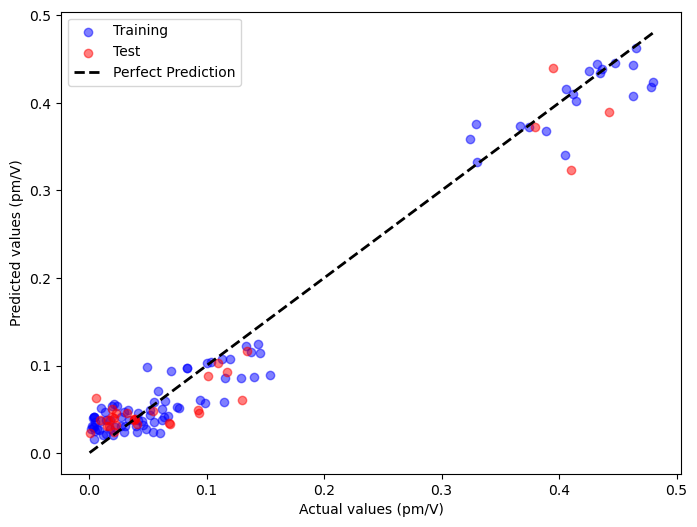

In [6]:
import numpy as np
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.kernel_ridge import KernelRidge
from sklearn.model_selection import GridSearchCV, KFold
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error

# Define the parameter grid for hyperparameter tuning
param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1.0, 10.0],  # Ridge regularization parameter
    'kernel': ['linear', 'rbf', 'poly'],  # Kernels to try
    'gamma': [0.01, 0.1, 1.0],  # Kernel coefficient (gamma) for 'rbf' and 'poly' kernels
}

# Create a Kernel Ridge Regression model
krr = KernelRidge()

# Perform 5-fold cross-validated grid search
grid_search = GridSearchCV(krr, param_grid, cv=KFold(n_splits=5, shuffle=True, random_state=42))
grid_search.fit(X_train, y_train)

# Get the best-tuned model
best_krr = grid_search.best_estimator_
print("Best Hyperparameters:", grid_search.best_params_)

# Predict on the test data using the best model
y_pred_test = best_krr.predict(X_test)
y_pred_train = best_krr.predict(X_train)

# Calculate R-squared (R²) and Root Mean Squared Error (RMSE) for test data
r2_test = r2_score(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

# Calculate R-squared (R²) and Root Mean Squared Error (RMSE) for train data
r2_train = r2_score(y_train, y_pred_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))

# Print R-squared (R²) and RMSE for test data
print("Test R-squared (R²):", r2_test)
print("Test Root Mean Squared Error (RMSE):", rmse_test)

# Print R-squared (R²) and RMSE for train data
print("Train R-squared (R²):", r2_train)
print("Train Root Mean Squared Error (RMSE):", rmse_train)

# Evaluate the model
mse_test = mean_squared_error(y_test, y_pred_test)
print(f"Mean Squared Error on Test Data: {mse_test}")

# Evaluate the model on training data
mse_train = mean_squared_error(y_train, y_pred_train)
print(f"Mean Squared Error on Training Data: {mse_train}")

plt.figure(figsize=(8, 6))

# Plot for training set
plt.scatter(y_train, y_pred_train, color='blue', alpha=0.5, label='Training')

# Plot for test set
plt.scatter(y_test, y_pred_test, color='red', alpha=0.5, label='Test')

# Line for comparison
min_val = min(min(y_train), min(y_test))
max_val = max(max(y_train), max(y_test))
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--', color='black', linewidth=2, label='Perfect Prediction')

plt.xlabel('Actual values (pm/V)')
plt.ylabel('Predicted values (pm/V)')
plt.legend()
plt.show()

In [7]:
import shap
# Create a Kernel SHAP explainer
explainer =  shap.KernelExplainer(best_krr.predict, X_train)
feature_name = X.columns.tolist()
# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_train)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 93/93 [06:04<00:00,  3.92s/it]


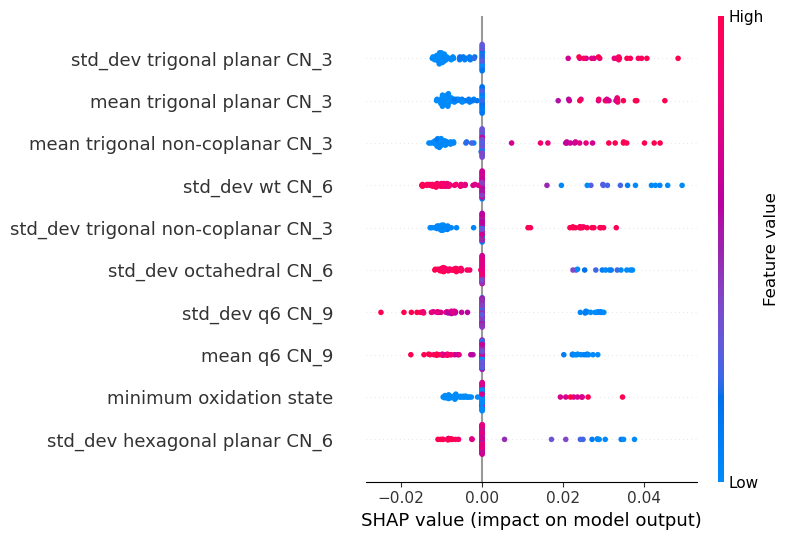

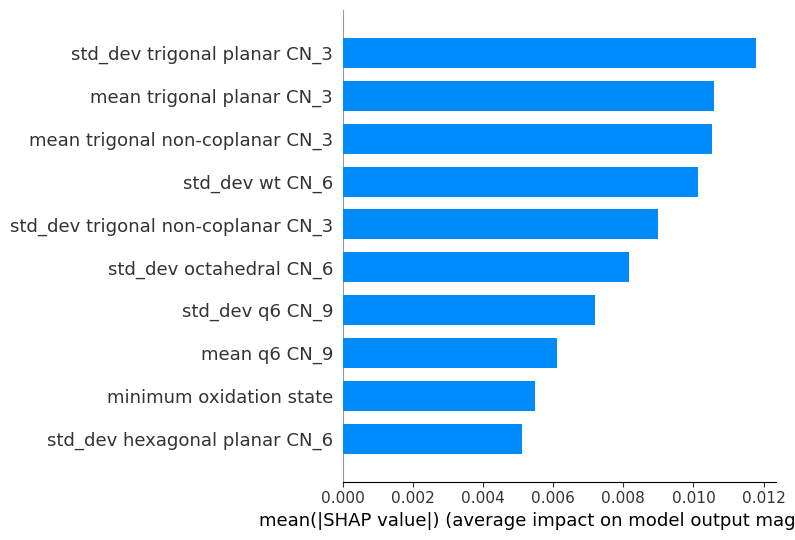

In [8]:
# Summary plot of SHAP values
shap.summary_plot(shap_values, X_train, feature_names=feature_name, max_display=10)
shap.summary_plot(shap_values, X_train, plot_type="bar", feature_names=feature_name, max_display=10)

Best Hyperparameters: {'learning_rate': 0.2, 'max_depth': 2, 'n_estimators': 100}
Test R-squared (R²): 0.9249598899728375
Test Root Mean Squared Error (RMSE): 0.034428576590772024
Train R-squared (R²): 0.9990015372124708
Train Root Mean Squared Error (RMSE): 0.004904189852588346
Mean Squared Error on Test Data: 0.0011853268860666556
Mean Squared Error on Training Data: 2.4051078110230504e-05


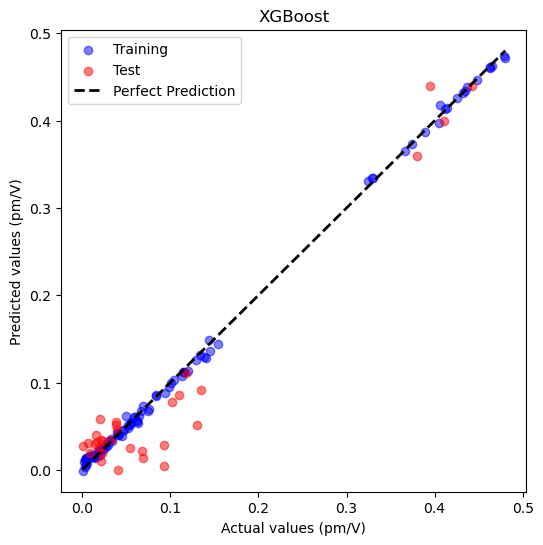

In [9]:
#XGBoost

import xgboost as xgb
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Create an XGBoost regressor
xg_reg = xgb.XGBRegressor(objective='reg:squarederror')

# Define the hyperparameter grid
param_grid = {
    'learning_rate': [0.001, 0.01, 0.1, 0.2],
    'max_depth': [2, 3, 4, 5, 6],
    'n_estimators': [20, 50, 100, 150, 200]
}

# Perform hyperparameter tuning using GridSearchCV
grid_search = GridSearchCV(xg_reg, param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)

# Get the best hyperparameters
best_params = grid_search.best_params_
print("Best Hyperparameters:", best_params)

# Train the final XGBoost model with the best hyperparameters
final_xg_reg = xgb.XGBRegressor(objective='reg:squarederror', **best_params)
final_xg_reg.fit(X_train, y_train)

# Make predictions on the training set
y_pred_train = final_xg_reg.predict(X_train)
# Make predictions on the test set
y_pred_test = final_xg_reg.predict(X_test)

# Calculate R-squared (R²) and Root Mean Squared Error (RMSE) for test data
r2_test = r2_score(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

# Calculate R-squared (R²) and Root Mean Squared Error (RMSE) for train data
r2_train = r2_score(y_train, y_pred_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))

# Print R-squared (R²) and RMSE for test data
print("Test R-squared (R²):", r2_test)
print("Test Root Mean Squared Error (RMSE):", rmse_test)

# Print R-squared (R²) and RMSE for train data
print("Train R-squared (R²):", r2_train)
print("Train Root Mean Squared Error (RMSE):", rmse_train)

# Evaluate the model
mse_test = mean_squared_error(y_test, y_pred_test)
print(f"Mean Squared Error on Test Data: {mse_test}")

# Evaluate the model on training data
mse_train = mean_squared_error(y_train, y_pred_train)
print(f"Mean Squared Error on Training Data: {mse_train}")

# Scatter plot for both training and test sets
plt.figure(figsize=(6, 6))

# Plot for training set
plt.scatter(y_train, y_pred_train, color='blue', alpha=0.5, label='Training')

# Plot for test set
plt.scatter(y_test, y_pred_test, color='red', alpha=0.5, label='Test')
# Line for comparison
min_val = min(min(y_train), min(y_test))
max_val = max(max(y_train), max(y_test))
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--', color='black', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual values (pm/V)')
plt.ylabel('Predicted values (pm/V)')
plt.title('XGBoost')
plt.legend()
plt.show()

In [10]:
explainer = shap.TreeExplainer(final_xg_reg)
shap_values = explainer.shap_values(X_train)

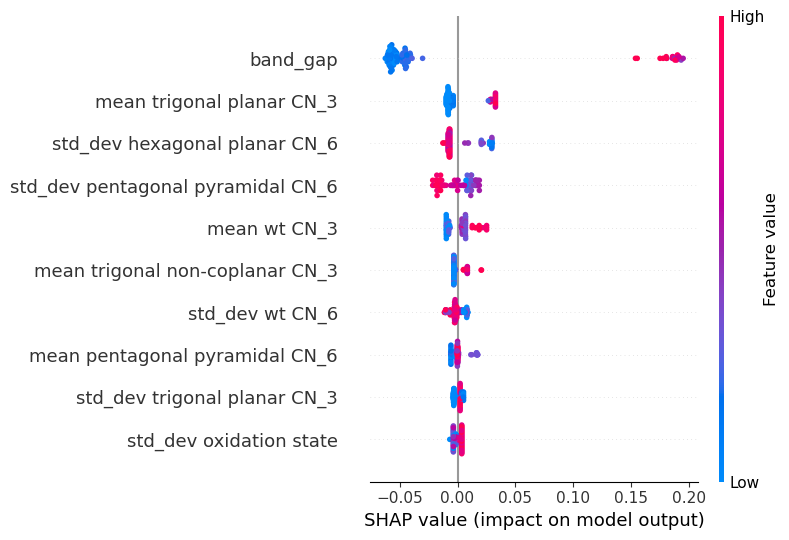

In [11]:
shap.summary_plot(shap_values, X_train, feature_names=feature_name, max_display=10)

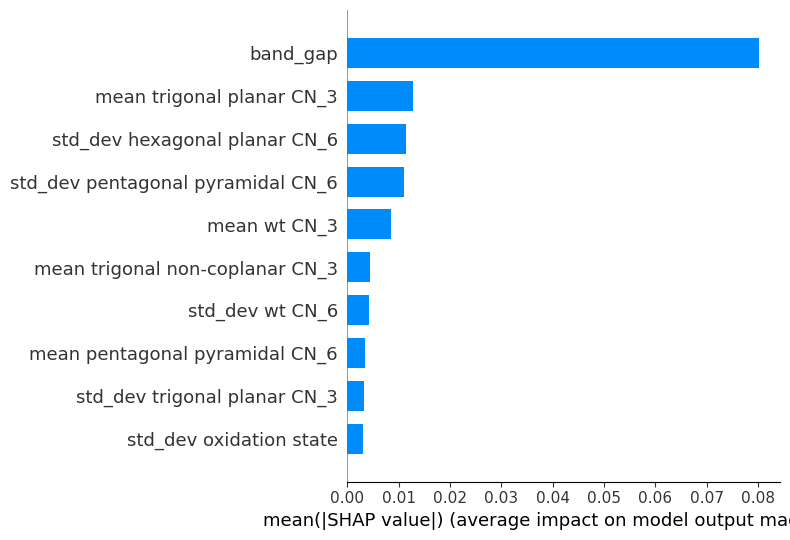

In [12]:
shap.summary_plot(shap_values, X_train, plot_type="bar", feature_names=feature_name, max_display=10)

### From the above Shap analysis we see that the piezoelectricity can be described by structural features only. We use this to make predictions on unseen data. We start with the relaxed POSCAR file and convert them as pymatgen structure object. This structure object is used within matminer to add structural features. The typical AL learning workflow is as shown below.

<img src="AL.png" width="400">

In [13]:
df_un = load_dataframe_from_json("unseen_mxene.json")

df_un.head()
df_un["Mxenes"] = df_un["name"].str.replace("-", "", regex=False)
exclude2 = ['magnetic_moment', 'isMetal', 'is_centrosymmetric', 'space_group', 'point_group']

df3 = df_un.drop(exclude2, axis=1)
df_feat1 = DensityFeatures()
df3 = df_feat1.featurize_dataframe(df3, "structure")  # input the structure column to the featurizer

from matminer.featurizers.conversions import StrToComposition
df3 = StrToComposition().featurize_dataframe(df3, "Mxenes")
from matminer.featurizers.conversions import CompositionToOxidComposition
from matminer.featurizers.composition import OxidationStates

df3 = CompositionToOxidComposition().featurize_dataframe(df3, "composition")

os_feat = OxidationStates()
df3 = os_feat.featurize_dataframe(df3, "composition_oxid")

Reading file unseen_mxene.json: 0it [00:00, ?it/s]0, ?it/s]
OxidationStates: 100%|███████████████████████████████████████████████████████████████████████████████████████| 53/53 [00:00<00:00, 159.55it/s]


In [14]:
from matminer.datasets.convenience_loaders import load_elastic_tensor
from matminer.featurizers.structure import SiteStatsFingerprint
cnnf = SiteStatsFingerprint.from_preset("CrystalNNFingerprint_ops")
df3 = cnnf.featurize_dataframe(df3, "structure", len(df["structure"][:])-1, True)

from matminer.featurizers.structure import SiteStatsFingerprint
from matminer.featurizers.site import AverageBondAngle, AverageBondLength
from pymatgen.analysis.local_env import CrystalNN

featurizer = SiteStatsFingerprint.from_preset('CrystalNNFingerprint_ops')

structures  = df3["structure"]

# Compute the features (bond lengths and angles) for each structure in the DataFrame
df3['features'] = structures.apply(lambda s: featurizer.featurize(s)[0])

#nnalgo = CrystalNN()
#bl = AverageBondLength(nnalgo)

#sspbl = SiteStatsFingerprint(site_featurizer=bl)
#df2 = sspbl.featurize_dataframe(df1, ignore_errors=True)
#print(df2)

SiteStatsFingerprint: 100%|██████████████████████████████████████████████████████████████████████████████████| 53/53 [00:00<00:00, 165.31it/s]


In [15]:
#Just a hack to make sure things are consistent across seen and unseen data
include =  ['compounds', 'total_piezo_tensor','total_dielectric_tensor', 'Piezo_31 (pm/V)','Piezo_33 (pm/V)', 'Piezo_11 (pm/V)','max_piezo']
df3.loc[:, include] = None
df3.head()

,name,band_gap,lattice_constant,num_sites,structure,Mxenes,density,vpa,packing fraction,composition,...,std_dev wt CN_24,SiteStatsFingerprint Exceptions,features,compounds,total_piezo_tensor,total_dielectric_tensor,Piezo_31 (pm/V),Piezo_33 (pm/V),Piezo_11 (pm/V),max_piezo
0,Nb-Cr-N-F-F,0.344,3.295,5.0,[[-1.66827547e-06 1.90291700e+00 8.74083616e...,NbCrNFF,1.083150,60.373903,0.087659,"(Nb, Cr, N, F)",...,0.0,NaN,0.000000,None,None,None,None,None,None,None
1,Nb-Cr-N-NCO-OH,0.226,3.185,8.0,[[-1.61231546e-06 1.83908626e+00 1.42755862e...,NbCrNNCOOH,1.198819,37.733690,0.098972,"(Nb, Cr, N, C, O, H)",...,0.0,NaN,0.362658,None,None,None,None,None,None,None
2,Nb-Cr-N-Cl-OCN,0.357,3.227,7.0,"[[1.61373798 0.93169017 5.93218782] C, [-1.633...",NbCrNClOCN,1.300285,43.124217,0.109634,"(Nb, Cr, N, Cl, O, C)",...,0.0,NaN,0.193445,None,None,None,None,None,None,None
3,Ta-Cr-N-Br-OH,0.411,3.302,6.0,[[-1.67165200e-06 1.90676844e+00 1.21619773e...,TaCrNBrOH,1.891534,50.311586,0.108508,"(Ta, Cr, N, Br, O, H)",...,0.0,NaN,0.248832,None,None,None,None,None,None,None
4,Ta-Cr-N-CN-Br,0.000,3.266,6.0,"[[1.63325795 0.94296 7.37097936] Br, [-1.65...",TaCrNCNBr,1.941097,50.311586,0.113864,"(Ta, Cr, N, C, Br)",...,0.0,NaN,0.230916,None,None,None,None,None,None,None



Iter 1 | Train size 20 | Pool size 85 | Test size 19
mu_max=4.625000e-01 | R2_test=0.8504 | MAE_test=4.4792e-02
  idx 120 name Y-Y-N-O-OCN score 1.1133e-03
  idx 57 name Sc-Sc-N-O-Br score 2.7893e-03
  idx 117 name Y-Y-N-O-Cl score 3.5031e-04
  idx 39 name Sc-Sc-C-O-O score 2.1501e-03
  idx 116 name Y-Y-N-O-Br score 4.0456e-03

Iter 2 | Train size 25 | Pool size 80 | Test size 19
mu_max=4.783000e-01 | R2_test=0.8616 | MAE_test=4.1768e-02
  idx 123 name Y-Y-N-SCN-O score 2.4841e-07
  idx 113 name Y-Y-N-CN-O score 3.2335e-07
  idx 114 name Y-Y-N-NCO-O score 1.0255e-06
  idx 58 name Sc-Sc-N-O-Cl score 5.1991e-07
  idx 55 name Sc-Sc-N-NCO-O score 1.8174e-05

Iter 3 | Train size 30 | Pool size 75 | Test size 19
mu_max=4.783000e-01 | R2_test=0.8609 | MAE_test=4.2053e-02
  idx 119 name Y-Y-N-O-H score 1.0229e-09
  idx 61 name Sc-Sc-N-O-OCN score 1.2691e-07
  idx 103 name Y-Y-C-O-O score 4.4439e-09
  idx 54 name Sc-Sc-N-CN-O score 5.5786e-13
  idx 118 name Y-Y-N-O-F score 1.4968e-07

Iter 4 |

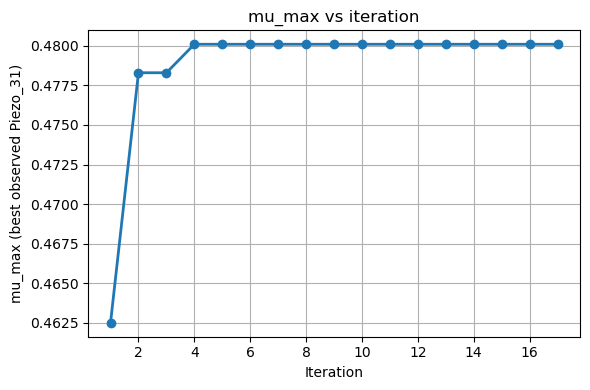

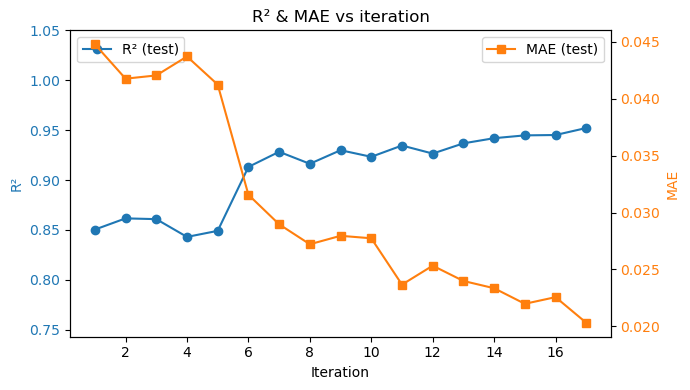

In [16]:
# Make predictions on unseen data using active learning. We use only structural features generates by matminer
# in both ML model training and predictions 
import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split

# -------------------------- Feature utilities --------------------------
def build_X_y_from_df(df, excluded_cols, target_col='Piezo_31 (pm/V)'):
    df_features = df.drop(excluded_cols, axis=1)
    X_all = df_features.values.astype(float)
    y_all = df[target_col].values.astype(float)
    feature_names = df_features.columns.tolist()
    return X_all, y_all, feature_names

def fit_preprocessor(X_train):
    vt = VarianceThreshold(threshold=0.0)
    vt.fit(X_train)
    X_train_vt = vt.transform(X_train)
    scaler = StandardScaler()
    scaler.fit(X_train_vt)
    return vt, scaler

def transform_with_preprocessor(X, vt, scaler):
    return scaler.transform(vt.transform(X))

# -------------------------- XGB ensemble helpers --------------------------
def train_xgb_ensemble_and_predict(X_train, y_train, X_targets,
                                   ensemble_size=50,
                                   n_estimators=100,
                                   learning_rate=0.2,
                                   max_depth=6,
                                   subsample=0.8,
                                   colsample_bytree=0.8,
                                   verbose=False):
    n_targets = X_targets.shape[0]
    preds = np.zeros((ensemble_size, n_targets), dtype=float)
    for i in range(ensemble_size):
        model = xgb.XGBRegressor(
            objective='reg:squarederror',
            n_estimators=n_estimators,
            max_depth=max_depth,
            subsample=subsample,
            colsample_bytree=colsample_bytree,
            random_state=i,
            n_jobs=1
        )
        model.fit(X_train, y_train, verbose=verbose)
        preds[i, :] = model.predict(X_targets)
    mu = preds.mean(axis=0)
    sigma = preds.std(axis=0, ddof=1)
    return preds, mu, sigma

def train_final_ensemble_models(X_train, y_train, ensemble_size=50, n_estimators=200, max_depth=6):
    models = []
    preds = []
    for i in range(ensemble_size):
        m = xgb.XGBRegressor(objective='reg:squarederror',
                             n_estimators=n_estimators,
                             max_depth=max_depth,
                             random_state=i,
                             n_jobs=1)
        m.fit(X_train, y_train, verbose=False)
        models.append(m)
    return models

def predict_with_models(models, X):
    all_preds = np.vstack([m.predict(X) for m in models])
    mu = all_preds.mean(axis=0)
    sigma = all_preds.std(axis=0, ddof=1)
    return all_preds, mu, sigma

# -------------------------- Acquisition functions --------------------------
def expected_improvement(mu, sigma, mu_max, epsilon=0.01):
    with np.errstate(divide='ignore', invalid='ignore'):
        z = (mu - mu_max - epsilon) / sigma
        Phi = norm.cdf(z)
        phi = norm.pdf(z)
        EI = (mu - mu_max - epsilon) * Phi + sigma * phi
        zero_mask = (sigma <= 0)
        EI[zero_mask] = np.maximum(0.0, mu[zero_mask] - mu_max - epsilon)
    return EI

def acquire_max(mu_pool, pool_idx, k):
    return pool_idx[np.argsort(-mu_pool)[:k]]

def acquire_stdev(sigma_pool, pool_idx, k):
    return pool_idx[np.argsort(-sigma_pool)[:k]]

def acquire_ei(mu_pool, sigma_pool, pool_idx, k, epsilon=0.01, mu_max=None):
    if mu_max is None:
        mu_max = np.max(mu_pool)
    EI = expected_improvement(mu_pool, sigma_pool, mu_max, epsilon)
    order = np.argsort(-EI)
    return pool_idx[order[:k]], EI

# -------------------------- Simple Mahalanobis distance --------------------------
def mahalanobis_distance_to_train(X_new_scaled, X_train_scaled):
    mu = X_train_scaled.mean(axis=0)
    cov = np.cov(X_train_scaled, rowvar=False)
    cov += np.eye(cov.shape[0]) * 1e-6
    inv_cov = np.linalg.inv(cov)
    d2 = np.sum((X_new_scaled - mu) @ inv_cov * (X_new_scaled - mu), axis=1)
    return np.sqrt(d2)

# -------------------------- Active Learning with eval --------------------------
def active_learning_xgb_with_eval(
    df,
    excluded_cols,
    target_col='Piezo_31 (pm/V)',
    test_size=0.15,
    initial_train_size=20,
    k_per_iter=5,
    max_iterations=10,
    ensemble_size=10,
    xgb_n_estimators=200,
    xgb_max_depth=6,
    strategy='EGO',
    epsilon_ei=0.01,
    random_seed=0,
    verbose=True
):
    X_all, y_all, feature_names = build_X_y_from_df(df, excluded_cols, target_col)
    n_total = X_all.shape[0]
    all_idx = np.arange(n_total)

    train_pool_idx, test_idx = train_test_split(all_idx, test_size=test_size, random_state=random_seed)
    rng = np.random.default_rng(random_seed)
    if initial_train_size >= len(train_pool_idx):
        raise ValueError("initial_train_size must be < number of training-pool samples")
    init_train_idx = rng.choice(train_pool_idx, size=initial_train_size, replace=False)
    pool_idx = np.setdiff1d(train_pool_idx, init_train_idx)
    train_idx = list(init_train_idx)

    X_test = X_all[test_idx]; y_test = y_all[test_idx]
    y_train = y_all[train_idx].copy()

    history = []

    for it in range(max_iterations):
        if verbose:
            print(f"\nIter {it+1} | Train size {len(train_idx)} | Pool size {len(pool_idx)} | Test size {len(test_idx)}")

        X_train = X_all[train_idx]; X_pool = X_all[pool_idx]
        vt, scaler = fit_preprocessor(X_train)
        X_train_scaled = transform_with_preprocessor(X_train, vt, scaler)
        X_pool_scaled = transform_with_preprocessor(X_pool, vt, scaler)
        X_test_scaled = transform_with_preprocessor(X_test, vt, scaler)

        preds_pool_all, mu_pool, sigma_pool = train_xgb_ensemble_and_predict(
            X_train_scaled, y_train, X_pool_scaled,
            ensemble_size=ensemble_size,
            n_estimators=xgb_n_estimators,
            max_depth=xgb_max_depth
        )


        preds_test_all, mu_test, sigma_test = train_xgb_ensemble_and_predict(
            X_train_scaled, y_train, X_test_scaled,
            ensemble_size=ensemble_size,
            n_estimators=xgb_n_estimators,
            max_depth=xgb_max_depth
        )

        r2 = r2_score(y_test, mu_test)
        mae = mean_absolute_error(y_test, mu_test)

        mu_max_observed = np.max(y_train)

        if strategy.upper() == 'MAX':
            selected = acquire_max(mu_pool, pool_idx, k_per_iter)
            sel_scores = mu_pool[np.isin(pool_idx, selected)]
        elif strategy.upper() == 'STDEV':
            selected = acquire_stdev(sigma_pool, pool_idx, k_per_iter)
            sel_scores = sigma_pool[np.isin(pool_idx, selected)]
        elif strategy.upper() == 'EGO':
            selected, EI = acquire_ei(mu_pool, sigma_pool, pool_idx, k_per_iter, epsilon=epsilon_ei, mu_max=mu_max_observed)
            sel_scores = EI[np.isin(pool_idx, selected)]
        else:
            raise ValueError("strategy must be MAX/STDEV/EGO")

        y_new = y_all[selected]  # offline mode: you have full labels
        train_idx.extend(list(selected))
        y_train = np.concatenate([y_train, y_new], axis=0)
        pool_idx = np.setdiff1d(pool_idx, selected)

        history.append({
            'iteration': it,
            'n_train': len(train_idx),
            'mu_max_observed': mu_max_observed,
            'r2_test': r2,
            'mae_test': mae,
            'selected_idx': selected,
            'selected_scores': sel_scores
        })

        if verbose:
            print(f"mu_max={mu_max_observed:.6e} | R2_test={r2:.4f} | MAE_test={mae:.4e}")
            for i, s in zip(selected[:5], sel_scores[:5]):
                nm = df.iloc[int(i)]['name'] if 'name' in df.columns else int(i)
                print(f"  idx {int(i)} name {nm} score {float(s):.4e}")

        if len(pool_idx) == 0:
            if verbose:
                print("Pool exhausted.")
            break

    return train_idx, test_idx, history, vt, scaler

# -------------------------- Plotting functions --------------------------
def plot_mu_max(history, filename=None, title="mu_max vs iteration"):
    it = [h['iteration']+1 for h in history]
    mu_max = [h['mu_max_observed'] for h in history]
    plt.figure(figsize=(6,4))
    plt.plot(it, mu_max, marker='o', linewidth=2)
    plt.xlabel('Iteration'); plt.ylabel('mu_max (best observed Piezo_31)')
    plt.title(title); plt.grid(True); plt.tight_layout()
    if filename: plt.savefig(filename, dpi=200)
    plt.show()

def plot_metrics(history, filename=None, title="R² & MAE vs iteration"):
    it = [h['iteration']+1 for h in history]
    r2 = [h['r2_test'] for h in history]
    mae = [h['mae_test'] for h in history]

    fig, ax1 = plt.subplots(figsize=(7,4))
    ax1.plot(it, r2, marker='o', label='R² (test)')
    ax1.set_xlabel('Iteration')
    ax1.set_ylabel('R²', color='C0')
    ax1.tick_params(axis='y', labelcolor='C0')
    ax1.set_ylim(min(r2)-0.1, 1.05)

    ax2 = ax1.twinx()
    ax2.plot(it, mae, marker='s', color='C1', label='MAE (test)')
    ax2.set_ylabel('MAE', color='C1')
    ax2.tick_params(axis='y', labelcolor='C1')

    plt.title(title)
    fig.tight_layout()
    ax1.legend(loc='upper left'); ax2.legend(loc='upper right')
    if filename: plt.savefig(filename, dpi=200)
    plt.show()

def plot_uncertainty_hist(sigma, filename=None, title="Histogram of predicted sigma"):
    plt.figure(figsize=(6,4))
    plt.hist(sigma, bins=30)
    plt.xlabel('Predicted sigma'); plt.ylabel('Count')
    plt.title(title); plt.grid(True); plt.tight_layout()
    if filename: plt.savefig(filename, dpi=200)
    plt.show()

def plot_topN_errorbars(unseen_df, mu, sigma, topN=20, filename=None, title="Top-N predictions ± sigma"):
    dfc = unseen_df.copy()
    dfc['_mu'] = mu
    dfc['_sigma'] = sigma
    dfc_sorted = dfc.sort_values('_mu', ascending=False).head(topN)
    x = np.arange(len(dfc_sorted))
    plt.figure(figsize=(8, max(4, topN*0.25)))
    plt.errorbar(x, dfc_sorted['_mu'], yerr=dfc_sorted['_sigma'], fmt='o', capsize=4)
    plt.xticks(x, dfc_sorted.index.astype(str), rotation=90)
    plt.xlabel('Unseen sample index'); plt.ylabel('Predicted Piezo_31')
    plt.title(title)
    plt.tight_layout(); plt.grid(True)
    if filename: plt.savefig(filename, dpi=200)
    plt.show()

def plot_pred_vs_true(unseen_df, mu, sigma, true_label_col=None, filename=None, title="Predicted vs True"):
    if true_label_col is None or true_label_col not in unseen_df.columns:
        raise ValueError("true_label_col must be provided and present in unseen_df to plot predicted vs true")
    y_true = unseen_df[true_label_col].values
    plt.figure(figsize=(6,6))
    plt.errorbar(y_true, mu, yerr=sigma, fmt='o', alpha=0.7, capsize=3)
    mn = min(min(y_true), min(mu)); mx = max(max(y_true), max(mu))
    plt.plot([mn, mx], [mn, mx], 'k--', alpha=0.6)
    plt.xlabel('True Piezo_31'); plt.ylabel('Predicted Piezo_31 (mean)')
    plt.title(title); plt.grid(True); plt.tight_layout()
    if filename: plt.savefig(filename, dpi=200)
    plt.show()

def plot_mahalanobis_hist(mdist, filename=None, title="Mahalanobis distance to train"):
    plt.figure(figsize=(6,4))
    plt.hist(mdist, bins=30)
    plt.xlabel('Mahalanobis distance'); plt.ylabel('Count')
    plt.title(title); plt.grid(True); plt.tight_layout()
    if filename: plt.savefig(filename, dpi=200)
    plt.show()

# -------------------------- Final train-and-predict with plotting --------------------------
def final_train_and_predict_and_plot(
    df,
    excluded_cols,
    train_idx,
    unseen_df,
    target_col='Piezo_31 (pm/V)',
    ensemble_size=10,
    xgb_n_estimators=200,
    xgb_max_depth=6,
    compute_extrapolation=True,
    topN=20,
    output_prefix="al_results"
):
    # build features & check columns
    X_all, y_all, feature_names = build_X_y_from_df(df, excluded_cols, target_col)
    # training arrays
    X_train = X_all[train_idx]; y_train = y_all[train_idx]

    # prepare unseen features; ensure column ordering matches
    unseen_features = unseen_df.drop(excluded_cols, axis=1, errors='ignore')
    if list(unseen_features.columns) != feature_names:
        if set(unseen_features.columns) >= set(feature_names):
            unseen_features = unseen_features[feature_names]
        else:
            raise ValueError("unseen_df features don't match training features")
    X_new = unseen_features.values.astype(float)

    # fit preprocessor on final training set
    vt, scaler = fit_preprocessor(X_train)
    X_train_scaled = transform_with_preprocessor(X_train, vt, scaler)
    X_new_scaled = transform_with_preprocessor(X_new, vt, scaler)

    # train final ensemble (models)
    models = train_final_ensemble_models(X_train_scaled, y_train, ensemble_size=ensemble_size,
                                         n_estimators=xgb_n_estimators, max_depth=xgb_max_depth)

    # predict unseen
    all_preds, mu, sigma = predict_with_models(models, X_new_scaled)

    # diagnostics: mahalanobis
    diagnostics = {}
    if compute_extrapolation:
        mdist = mahalanobis_distance_to_train(X_new_scaled, X_train_scaled)
        diagnostics['mahalanobis'] = mdist
        diagnostics['extrapolation_flag'] = mdist > 3.0
    diagnostics['sigma_train'] = np.std(all_preds, axis=0, ddof=1)

    # create results dataframe
    results = unseen_df.copy()
    results['_pred_mu'] = mu
    results['_pred_sigma'] = sigma
    if 'mahalanobis' in diagnostics:
        results['_mahalanobis'] = diagnostics['mahalanobis']

    # Plotting
    plot_uncertainty_hist(sigma, filename=f"{output_prefix}_sigma_hist.png")
    plot_topN_errorbars(results, mu, sigma, topN=topN, filename=f"{output_prefix}_top{topN}_errorbars.png")
    if '_mahalanobis' in results.columns:
        plot_mahalanobis_hist(results['_mahalanobis'].values, filename=f"{output_prefix}_mahalanobis_hist.png")

    # Save results CSV
    results.to_csv(f"{output_prefix}_unseen_predictions.csv", index=False)
    print(f"Saved predictions to {output_prefix}_unseen_predictions.csv and plots with prefix {output_prefix}_*.png")

    return results, diagnostics, models

# 1) Run active learning to get labelled train_idx and history
train_idx, test_idx, history, vt_al, scaler_al = active_learning_xgb_with_eval(
     df=df,
     excluded_cols=excluded,
     target_col='Piezo_31 (pm/V)',
     test_size=0.15,
     initial_train_size=20,
     k_per_iter=5,
     max_iterations=20,
     ensemble_size=10,
     xgb_n_estimators=200,
     xgb_max_depth=6,
     strategy='EGO',
     epsilon_ei=0.01,
     random_seed=42,
     verbose=True
 )
#
# # 2) Plot AL metrics
plot_mu_max(history, filename="mu_max_iter.png")
plot_metrics(history, filename="r2_mae_iter.png")

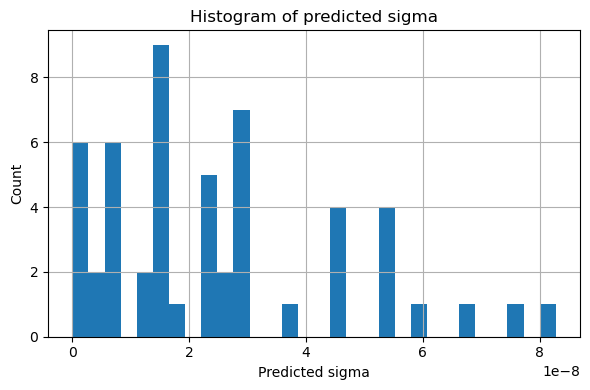

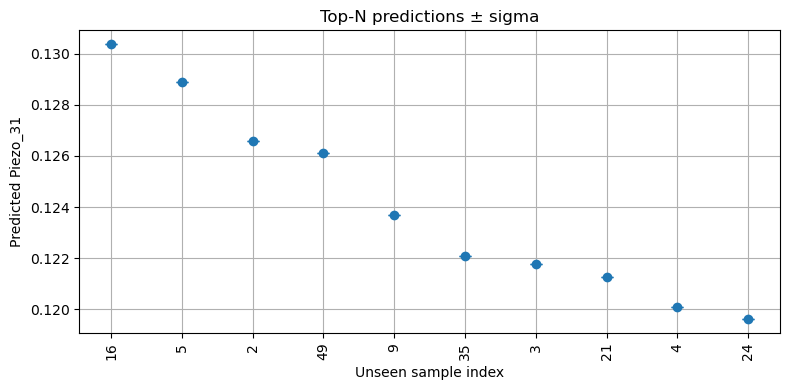

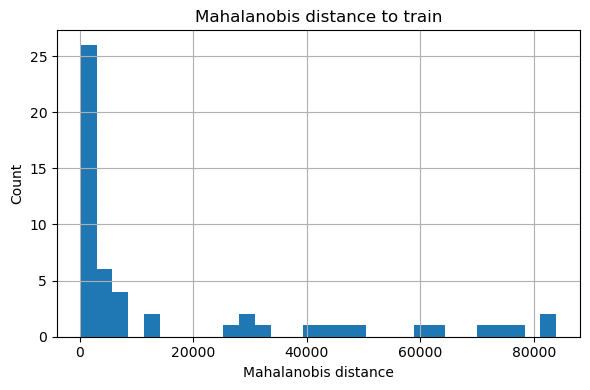

Saved predictions to al_results_unseen_predictions.csv and plots with prefix al_results_*.png


In [17]:
results, diagnostics, models = final_train_and_predict_and_plot(
     df=df,
     excluded_cols=excluded,
     train_idx=train_idx,
     unseen_df=df3,
     target_col='Piezo_31 (pm/V)',
     ensemble_size=50,
     xgb_n_estimators=200,
     xgb_max_depth=6,
     compute_extrapolation=True,
     topN=10,
     output_prefix="al_results"
)

In [18]:
topN = results.sort_values('_pred_mu', ascending=False).head(10)
print(topN[['name', '_pred_mu', '_pred_sigma']])

              name  _pred_mu   _pred_sigma
16  Ta-Cr-N-Br-OCN  0.130384  1.505245e-08
5   Ta-Cr-N-Cl-OCN  0.128908  4.515734e-08
2   Nb-Cr-N-Cl-OCN  0.126583  1.505245e-08
49   Nb-Cr-N-H-OCN  0.126111  0.000000e+00
9   Nb-Cr-N-NCS-Cl  0.123690  5.268356e-08
35   Ta-Cr-N-Cl-OH  0.122095  3.010489e-08
3    Ta-Cr-N-Br-OH  0.121760  2.257867e-08
21   Ta-Cr-N-Br-Br  0.121252  7.526223e-09
4    Ta-Cr-N-CN-Br  0.120085  1.505245e-08
24    Ta-Cr-N-CN-H  0.119606  3.010489e-08


In [19]:
def plot_topN_errorbars(unseen_df, mu, sigma, topN=20, filename=None,
                        title="Top-N predictions ± sigma", dft_points=None):
    # copy + attach predictions
    dfc = unseen_df.copy()
    dfc['_mu'] = mu
    dfc['_sigma'] = sigma

    # sort by predicted mean
    dfc_sorted = dfc.sort_values('_mu', ascending=False).head(topN)

    # use names if available
    if 'name' in dfc_sorted.columns:
        labels = dfc_sorted['name'].tolist()
    elif 'Mxenes' in dfc_sorted.columns:
        labels = dfc_sorted['Mxenes'].tolist()
    else:
        labels = dfc_sorted.index.astype(str).tolist()

    x = np.arange(len(dfc_sorted))

    plt.figure(figsize=(max(8, topN*0.4), 5))

    # Plot predictions with error bars, keep handle to retrieve colors
    container = plt.errorbar(x, dfc_sorted['_mu'], yerr=dfc_sorted['_sigma'],
                             fmt='o', capsize=4, markersize=6, label='Predictions')

    # If DFT points provided, plot them in same color as prediction
    if dft_points is not None:
        for idx, val in dft_points:
            if idx in dfc_sorted.index:  
                x_pos = dfc_sorted.index.get_loc(idx)
                color = "red"
                plt.plot(x_pos, val, 's', markersize=7, color=color,
                         label='DFT verified' if 'DFT verified' not in plt.gca().get_legend_handles_labels()[1] else "")
            elif idx in labels:
                x_pos = labels.index(idx)
                color = container[0].get_color()
                plt.plot(x_pos, val, 's', markersize=7, color=color,
                         label='DFT verified' if 'DFT verified' not in plt.gca().get_legend_handles_labels()[1] else "")

    plt.xticks(x, labels, rotation=90, fontsize=8)
    plt.xlabel('System')
    plt.ylabel('Predicted Piezo_31 (pm/V)')
    plt.title(title)
    plt.grid(True, axis='y', linestyle='--', alpha=0.6)
    plt.legend()
    plt.tight_layout()

    if filename:
        plt.savefig(filename, dpi=200)
    plt.show()

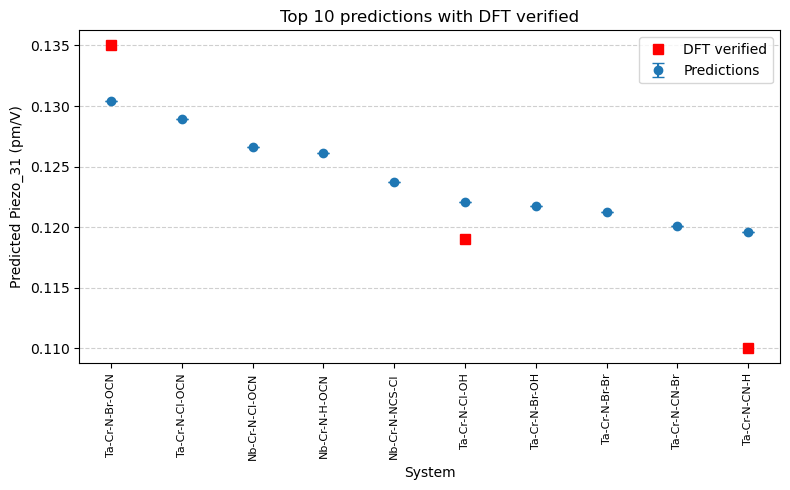

In [20]:
dft_points = [
    (16, 0.135),
    (35, 0.119),
    (24, 0.11),
]

plot_topN_errorbars(
    unseen_df=results,
    mu=results['_pred_mu'].values,
    sigma=results['_pred_sigma'].values,
    topN=10,
    title="Top 10 predictions with DFT verified",
    dft_points=dft_points
)